
# Lab_3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Solve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with the Fourier serie. How many terms in the fourier serie are necessary to obtain a $\text{tol}=10^{-3}$?


#### **Exercise 2**: FDM for oppen boundaries (optional)

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="300" height="400" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** (laboratorio 4)

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

**Solución Ejercicio 1**

In [8]:
#Solución con Jacobi

#Parámetros del problema 

L = 1.0 # Tamaño del dominio
V0 = 100 # Potencial en y = 0

Nx = 100
Ny = 100

tol = 1e-3 # Tolerancia solicitada para Jacobi
max_iter = 100000

x = np.linspace(0, L, Nx)
y = np.linspace(0, L, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

# Matriz u[y,x]
u = np.zeros((Ny, Nx))

# Condiciones de frontera
u[0, 1:-1] = V0 # u(x,0) = 100V
u[:,0] = 0 # u(0,y) = 0
u[:,-1] = 0 # u(L,y) = 0
u[-1,:] = 0 # u(x,L)


# Método de Jacobi
for iteracion in range(max_iter):
    u1 = u.copy()

    # u(i,j) = 1/4 [u(i+1,j) + u(i-1,j)
    #               +u(i,j+1) + u(i,j-1)]    
    u1[1:-1, 1:-1] = 0.25 * (u[1:-1,2:] + u[1:-1, :-2] + u[2:, 1:-1] + u[:-2, 1:-1])

    error = np.max(np.abs(u1-u))
    u = u1

    if error < tol:
        break

print ('Método de Jacobi \nTolerancia =', tol,'\nIteraciones =', iteracion+1, '\nError final =', error)

Método de Jacobi 
Tolerancia = 0.001 
Iteraciones = 5991 
Error final = 0.0009998893285754207


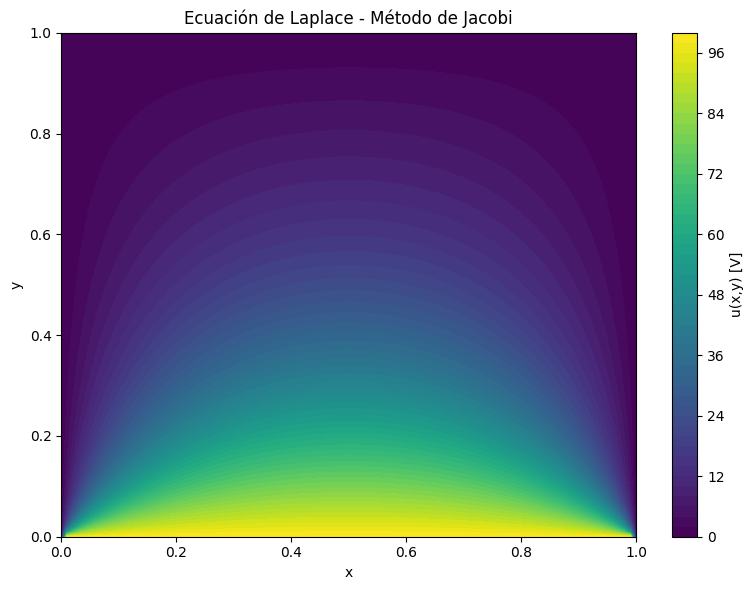

In [9]:
#Gráfica
X, Y = np.meshgrid(x, y)
plt.figure(figsize=(8,6))
contour = plt.contourf(X,Y, u, levels=50)
plt.colorbar(contour, label='u(x,y) [V]')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ecuación de Laplace - Método de Jacobi')

plt.tight_layout()
plt.show()

Inicialmente se inicializa una matriz en la que los puntos interiores se toman como cero. Después Jacobi toma cada punto interior y calcula:

$
\begin{aligned}
u_{i,j}^{(k+1)}=\frac{u_{i+1,j}^{(k)}+u_{i-1,j}^{(k)}+u_{i,j+1}^{(k)}+u_{i,j-1}^{(k)}}{4}
\end{aligned}
$

Es decir, cada punto interior se convierte en el promedio de sus cuatro vecinos (K representa el número de iteraciones). Esto se repite hasta que

$max_{i,j}\lvert{u_{i,j}^{(k+1)}-u_{i,j}^{(k)}}<10^{-3}\rvert$

Esa es la definición que se usó de tolerancia.

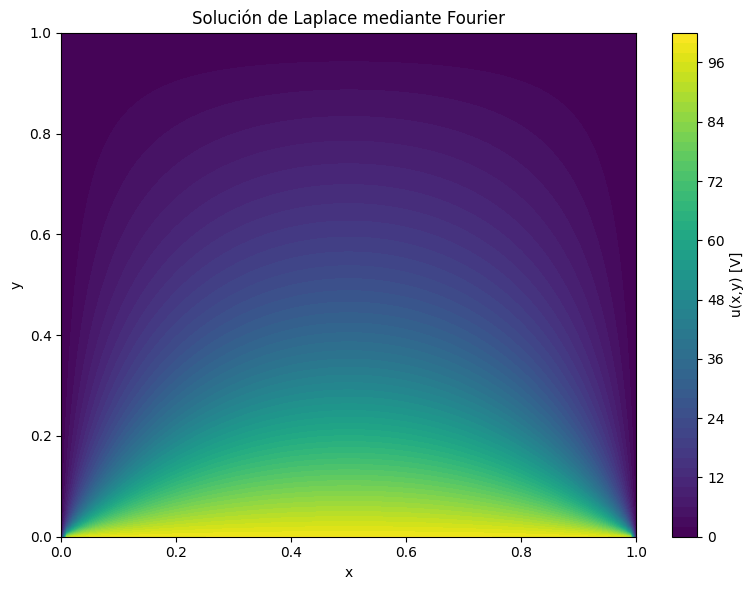

In [11]:
#Solución Fourier

def fourier_solution(num_terms, X, Y, L=1.0, V0=100.0):
    u_fourier = np.zeros_like(X)

    for k in range(1, num_terms + 1):
        # Solo aparecen números impares:
        n = 2*k - 1

        # Cociente hiperbólico escrito de forma estable
        ratio = (np.exp(-n*np.pi*Y/L)- np.exp(-n*np.pi*(2 - Y/L))) / (1 - np.exp(-2*n*np.pi)) #para evitar que cuando n crezca el código presente error
        u_fourier += (4*V0/(n*np.pi)* np.sin(n*np.pi*X/L)* ratio)

    return u_fourier

u_fourier = fourier_solution(100, X, Y)

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, u_fourier,levels=50)
plt.colorbar(contour, label="u(x,y) [V]")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solución de Laplace mediante Fourier")

plt.tight_layout()
plt.show()

In [14]:
tol_fourier = 1e-4
previous = None

for terms in range(1, 300):
    current = fourier_solution(terms, X, Y)
    if previous is not None:
        # No incluimos la frontera porque allí existen discontinuidades en las esquinas
        error = np.max(
            np.abs(current[1:-1, 1:-1]- previous[1:-1, 1:-1]))

        if error < tol_fourier:
            print("Convergencia de Fourier")
            print(f"Tolerancia = {tol_fourier}")
            print(f"Términos = {terms}")
            print(f"Mayor n utilizado = {2*terms - 1}")
            print(f"Error = {error:.6e}")

            break

    previous = current

Convergencia de Fourier
Tolerancia = 0.0001
Términos = 50
Mayor n utilizado = 99
Error = 0.000000e+00


**Solución Ejercicio 3**

Convergió en 3260 iteraciones
Error = 9.995e-07


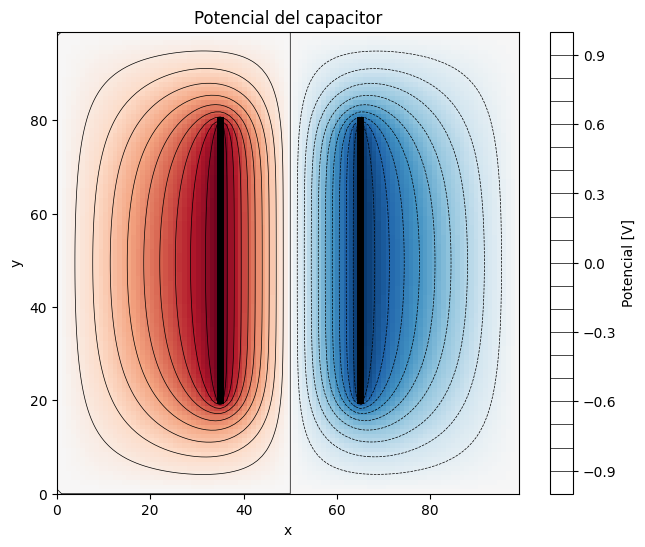

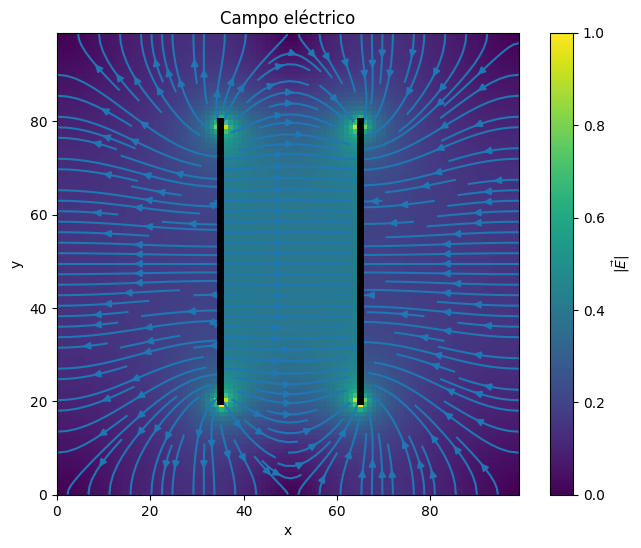

In [39]:
#Malla
N = 100                      # nodos por lado
phi = np.zeros((N, N))       # potencial 
tol = 1e-6
max_iter = 10000
 
#Placas verticales (dos columnas fijas)
x1, x2 = 35, 65              # posicion (columna) de cada placa
y1, y2 = 20, 80              # las placas van de y1 a y2
 
phi[x1, y1:y2] = 1.0         # placa izquierda a +1 V
phi[x2, y1:y2] = -1.0        # placa derecha a -1 V
 
#Resolver Laplace por diferencias finita
for iteración in range(max_iter):
    phi_new = phi.copy()
    phi_new[1:-1, 1:-1] = 0.25 * (phi[2:, 1:-1] + phi[:-2, 1:-1] + phi[1:-1, 2:] + phi[1:-1, :-2])
    # volver a fijar las placas (no cambian)
    phi_new[x1, y1:y2] = 1.0
    phi_new[x2, y1:y2] = -1.0

    error = np.max(np.abs(phi_new - phi))
    phi = phi_new

    if error < tol:
        print(f'Convergió en {iteración+1} iteraciones')
        print(f"Error = {error:.3e}")
        break

#Campo Eléctrico

dx = 1.0
dy = 1.0

# phi está almacenado como phi[x,y]
Ex, Ey = np.gradient(-phi, dx, dy)
E = np.sqrt(Ex**2 + Ey**2)

x = np.arange(N)
y = np.arange(N)
X, Y = np.meshgrid(x, y)

#Gráfica Potencial
plt.figure(figsize=(8, 6))
plt.imshow(phi.T, origin="lower", extent=[0, N-1, 0, N-1], aspect="equal", cmap="RdBu_r", vmin=-1, vmax=1)
levels = np.linspace(-1, 1, 21) # Líneas equipotenciales
plt.contour(X, Y, phi.T, levels=levels, colors="black", linewidths=0.5)

# Dibujar explícitamente las placas
plt.plot([x1, x1], [y1, y2], linewidth=5, color="black")
plt.plot([x2, x2], [y1, y2], linewidth=5, color="black")
plt.colorbar(label="Potencial [V]")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Potencial del capacitor")
plt.show()

#Gráfica Campo Eléctrico 
plt.figure(figsize=(8, 6))
plt.imshow(E.T, origin="lower", extent=[0, N-1, 0, N-1], aspect="equal", cmap="viridis")
plt.streamplot(x, y, Ex.T, Ey.T, density=1.5) # Líneas de campo
plt.plot([x1, x1], [y1, y2], linewidth=5, color="black")
plt.plot([x2, x2], [y1, y2], linewidth=5, color="black")
plt.colorbar(label=r"$|\vec{E}|$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo eléctrico")
plt.show()